**Best Pittsburgh Neighborhood — Economic Advantage Score (EAS)**
To analyze the best neighborhood in Pittsburgh, I created an Economic Advantage Score that compares each neighborhood's aggregate household income to the average U.S. household income ($74,580). This can create a general image of which neighborhoods have stronger financial resources overall.

In this scenario, a higher score means the neighborhood's total income is higher compared to the U.S. average, which can reflect strong economic well-being.

In [6]:
# Rename long ACS column names
import pandas as pd

df = pd.read_csv("aggregate-household-income-in-the-past-12-months-in-2014-inflation-adjusted-dollars (1).csv")
df = df.rename(columns={
    "Estimate; Aggregate household income in the past 12 months (in 2014 Inflation-adjusted dollars)": "Aggregate_Income",
    "Margin of Error; Aggregate household income in the past 12 months (in 2014 Inflation-adjusted dollars)": "MoE_Aggregate_Income"
})

# Convert numeric columns to numbers
df["Aggregate_Income"] = pd.to_numeric(df["Aggregate_Income"].astype(str).str.replace(",", ""), errors="coerce")

# U.S. average household income constant
US_AVG_INCOME = 74580

# Compute score
df["Economic_Advantage_Score"] = df["Aggregate_Income"] / US_AVG_INCOME

# Rank neighborhoods
ranked = df.sort_values("Economic_Advantage_Score", ascending=False).reset_index(drop=True)

# Show top 10
ranked.head(10)


,Neighborhood,Id,Aggregate_Income,MoE_Aggregate_Income,Economic_Advantage_Score
0,Squirrel Hill South,78,639717500.0,55105248.88,8577.601234
1,Shadyside,69,597347500.0,63123196.01,8009.486457
2,Squirrel Hill North,77,561576600.0,63708211.63,7529.855189
3,Brookline,14,361244500.0,34273834.17,4843.718155
4,Point Breeze,64,299866100.0,32033559.8,4020.730759
5,Mount Washington,54,263764100.0,23388926.99,3536.659962
6,Bloomfield,10,243725500.0,19774185.15,3267.973988
7,South Side Flats,73,240068000.0,29292476.83,3218.932690
8,Greenfield,37,235978800.0,25966033.36,3164.102977
9,Carrick,16,221566800.0,27495885.3,2970.860821


This table shows the **top neighborhoods** with the highest Economic Advantage Scores. These neighborhoods have the strongest total income compared to the U.S. average. 

Here is the table in a graph-format:

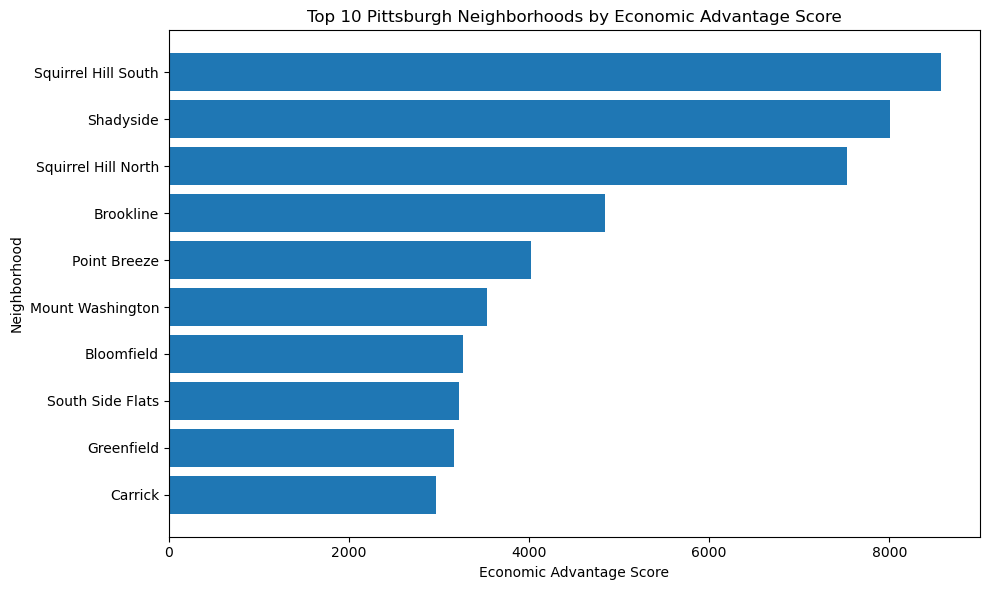

In [7]:
import matplotlib.pyplot as plt
top10 = ranked.loc[:9, ["Neighborhood", "Economic_Advantage_Score"]]

plt.figure(figsize=(10, 6))
plt.barh(top10["Neighborhood"], top10["Economic_Advantage_Score"])
plt.xlabel("Economic Advantage Score")
plt.ylabel("Neighborhood")
plt.title("Top 10 Pittsburgh Neighborhoods by Economic Advantage Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Conclusion

In this project, I measured the economic strength of each Pittsburgh neighborhood using 

### Easy-to-understand formula:
**Economic Advantage Score = Neighborhood's Total Income ÷ U.S. Average Household Income**

This tells us how many “units” of the average U.S. household income exist within a neighborhood’s total income.  
For example, a score of 8,000 means the neighborhood’s total income is roughly equal to the income of **8,000 average U.S. households** combined.

Using this calculation, the neighborhood with the **highest Economic Advantage Score**, and therefore the strongest overall financial resources, is:

**Squirrel Hill South**

(This is the first neighborhood shown in your ranked table.)

This score suggests that **Squirrel Hill South** has the highest total income relative to all other neighborhoods, meaning it may have more financial resources, greater economic activity, and potentially more opportunities for residents.

While this metric only measures the economic perspective, combining it with other factors (like safety, walkability, or green space) would provide a more complete picture of the “best” neighborhood in Pittsburgh.


**Introduction**

The metric I have decided to use is fire incidents, and I will be finding the best neighborhood by this metric based on which neighborhood has the fewest number of fire incidents.

The dataset I am using for this is from the City of Pittsburgh using data from the Pittsburgh Bureau of Fire to record incidents of fire responded to by them.

Here is a link to the WPRDC page: https://data.wprdc.org/dataset/fire-incidents-in-city-of-pittsburgh

Below, I have created a bar graph showing all of the neighborhoods in Pittsburgh with how many fire incidents they have had, ordered from least to most.

I believe that the neighborhood with the fewest fire incidents must be the best neighborhood in Pittsburgh by this metric, as it means it would very likely be the safest neighborhood. Someone who lives there would, at the very least, be much less likely to be in danger at any given moment compared to other neighborhoods within Pittsburgh.

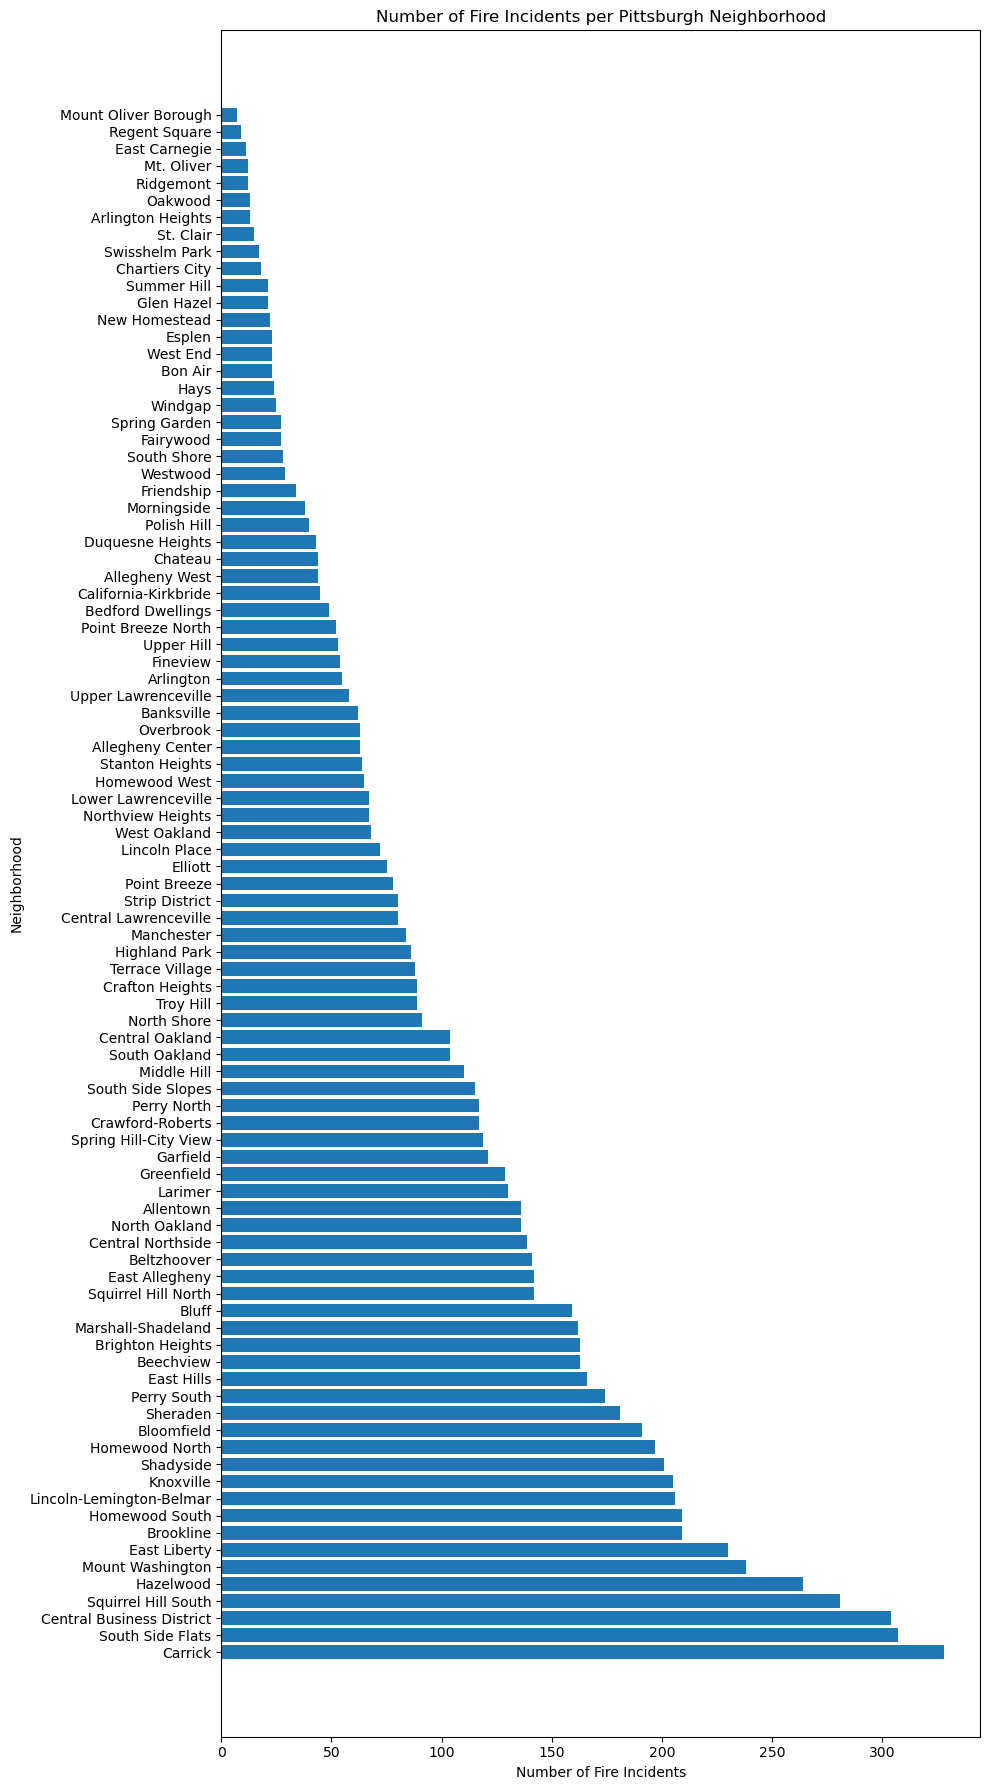

The best neighborhood in terms of fire incidents is Mount Oliver Borough with 7 incidents.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

fires = pd.read_csv("fire_incidents.csv")

counts = fires['neighborhood'].value_counts()
counts = counts.reset_index()
counts.columns = ['Neighborhood', 'Fires']

plt.figure(figsize=(10, 18))
plt.barh(counts['Neighborhood'], counts['Fires'])
plt.title("Number of Fire Incidents per Pittsburgh Neighborhood")
plt.xlabel("Number of Fire Incidents")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()

leastIncs = counts.iloc[-1]
leastNum = counts.min()

print("The best neighborhood in terms of fire incidents is " + str(leastIncs['Neighborhood']) + " with " + str(leastNum['Fires']) + " incidents.")

**Conclusion**

Using this data, the best neighborhood in Pittsburgh is Mount Oliver Borough, with only 7 incidents overall. I don't really have a "favorite" neighborhood here in Pittsburgh, considering I've only been here for about 4 months, but I will say that many of the more popular neighborhoods (from what I was able to find) placed rather low on this list. I think this can largely be attributed to the fact that this method of determining the best neighborhood largely ignores population size, and more populous neighborhoods will obviously have more fires just by virtue of having more people. However, it can still be argued that Mount Oliver Borough is the best neighborhood via this metric assuming you are able to live there since it has the least fires and would be among the safest neighborhoods in the city, if not the safest.

**Introduction**

The metric that I decided to use was non-traffic citations. I thought that crime plays a big role when choosing a good neighborhood. Before arriving at this answer, I also thought about traffic levels, job opportunites, and parks.

I am using the data set of non-traffic violations in Pittsburgh from the WPRDC.

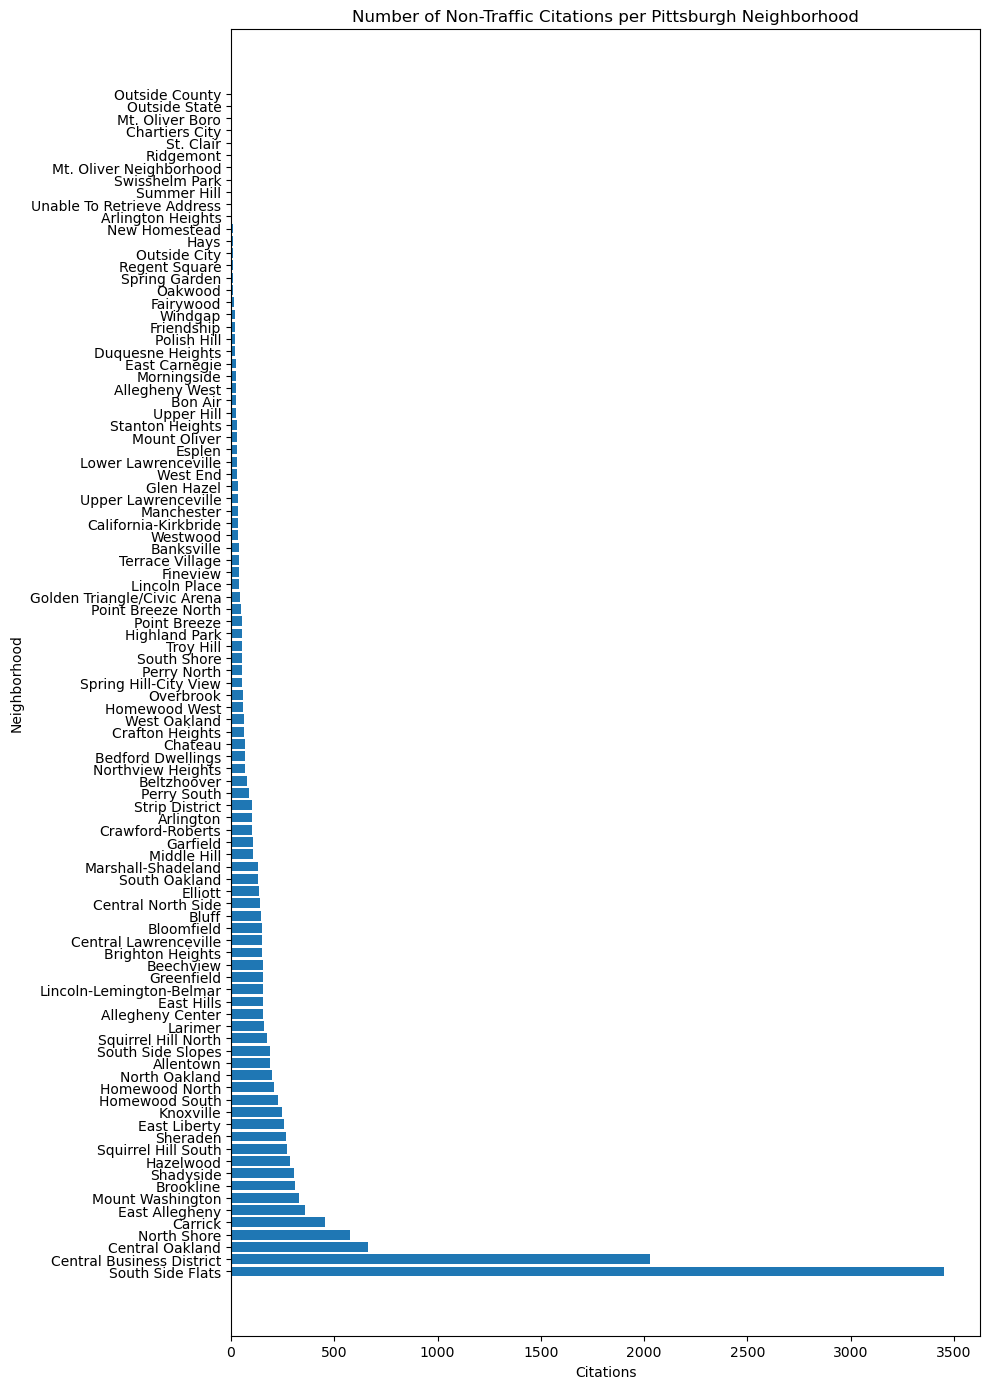

Neighborhood with the least citations: Outside County
Number of citations: 2


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

citations = pd.read_csv("citations.csv")

counts = citations['NEIGHBORHOOD'].value_counts()
counts = counts.reset_index()
counts.columns = ['Neighborhood', 'Citation_Count']
counts = counts.sort_values(by='Citation_Count', ascending=False)

plt.figure(figsize=(10, 14))
plt.barh(counts['Neighborhood'], counts['Citation_Count'])
plt.title("Number of Non-Traffic Citations per Pittsburgh Neighborhood")
plt.xlabel("Citations")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()

best_neighborhood = counts.iloc[-1]
print("Neighborhood with the least citations:", best_neighborhood['Neighborhood'])
print("Number of citations:", best_neighborhood['Citation_Count'])

From the data set, we can see that Outside County has the least amount of non-traffic violations. However, Outside State and Mt. Oliver Boro followed closely behind.

**Conclusion**

Considering I haven't been to many neighborhoods in Pittsburgh, these "best" neighborhoods certainly aren't my favorite because I haven't even heard of them. My favorite neighborhoods are Central Oakland and the Central Business District. Both of these neighborhoods were ranked very low on this list, but that's because they are much more populated than others.

**Introduction**

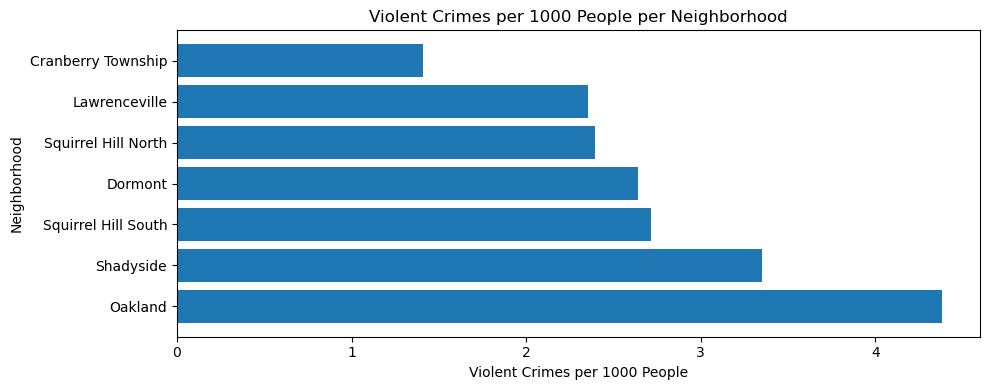

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

crimes = pd.read_csv("crime.csv")
crimes.columns = crimes.columns.str.strip()

counts = crimes[['Neighborhood', 'Crimerate']].copy()
counts = counts.sort_values(by='Crimerate', ascending=False)

plt.figure(figsize=(10, 4))
plt.barh(counts['Neighborhood'], counts['Crimerate'])
plt.title("Violent Crimes per 1000 People per Neighborhood")
plt.xlabel("Violent Crimes per 1000 People")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()

**Conclusion**

# Best Neighborhood



In [44]:
import pandas as pd

crimes = pd.read_csv("crime.csv")
citations = pd.read_csv("citations.csv")
fires = pd.read_csv("fire_incidents.csv")
df = pd.read_csv("aggregate-household-income-in-the-past-12-months-in-2014-inflation-adjusted-dollars (1).csv")
df = df.rename(columns={
    "Estimate; Aggregate household income in the past 12 months (in 2014 Inflation-adjusted dollars)": "Aggregate_Income",
    "Margin of Error; Aggregate household income in the past 12 months (in 2014 Inflation-adjusted dollars)": "MoE_Aggregate_Income"
})
crimes.columns = crimes.columns.str.strip()

crimecounts = crimes[['Neighborhood', 'Crimerate']].copy()
crimecounts = counts.sort_values(by='Crimerate', ascending=False)

citations = citations['NEIGHBORHOOD'].value_counts()
citations = citations.reset_index()
citations.columns = ['Neighborhood', 'Citation_Count']
citations = citations.sort_values(by='Citation_Count', ascending=False)

firecounts = fires['neighborhood'].value_counts()
firecounts = firecounts.reset_index()
firecounts.columns = ['Neighborhood', 'Fires']
firecounts = firecounts.sort_values(by='Fires',ascending=False)

df["Aggregate_Income"] = pd.to_numeric(df["Aggregate_Income"].astype(str).str.replace(",", ""), errors="coerce")
US_AVG_INCOME = 74580
df["Economic_Advantage_Score"] = df["Aggregate_Income"] / US_AVG_INCOME
ranked = df.sort_values("Economic_Advantage_Score", ascending=False)

totals = {neighborhood: idx+1
    for idx, neighborhood in citations["Neighborhood"].items()}
appearance_counts = {neighborhood: 1
    for neighborhood in citations["Neighborhood"]}

for idx, neighborhood in firecounts["Neighborhood"].items():  
        totals[neighborhood] = totals.get(neighborhood, 0) + idx
        appearance_counts[neighborhood] = appearance_counts.get(neighborhood,0)+1
for idx, neighborhood in crimecounts["Neighborhood"].items():   
        totals[neighborhood] = totals.get(neighborhood, 0) + idx
        appearance_counts[neighborhood] = appearance_counts.get(neighborhood,0)+1
for idx, neighborhood in df["Neighborhood"].items(): 
        totals[neighborhood] = totals.get(neighborhood, 0) + idx
        appearance_counts[neighborhood] = appearance_counts.get(neighborhood,0)+1

for neighborhood in appearance_counts:
    if appearance_counts.get(neighborhood, 0) != 4:
        totals[neighborhood] = 0

final_totals = dict(
    sorted(
        ((neighborhood, total) for neighborhood, total in totals.items() if total != 0),
        key=lambda item: item[1]
    ))
print('The best neighborhood is', next(iter(final_totals)))

The best neighborhood is Shadyside


**Final Conclusion**

I sorted through all of the databases and added up the indices of each neighborhood. All neighborhoods and total ranks were stored in a dictionary, which was then sorted. The lowest total was deemed the "best" neighborhood because it ranked the highest overall. Shadyside has been deemed the best neighborhood!